# Homework 4

Due: December 4 at 11:59 PM EST

Author: Pratham Mehta (cbm4kx)


## Question 1: Policymaker testing vaccinatin strategies 

In [1]:
# Part (i) - Create the world (Barabasi–Albert graph)

import networkx as nx
import numpy as np

n = 100 ## nodes
m = 2 ## edges added per new node
# Create BA graph
G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=42)

# sanity check
print(G_ba.number_of_nodes())
print(G_ba.number_of_edges())


100
196


In [2]:
# Part (ii) - Vaccination coverage fractions

# Fractions of population to vaccinate, from 0.1 to 1.0 inclusive (101 values)
vaccination_fracs = np.linspace(0.1, 1.0, 101)

## testing 
# vaccination_fracs[0] == 0.1, vaccination_fracs[-1] == 1.0


In [3]:
# Part (iii) - Prepare storage for results
#  record the average final fraction recovered (R / n_non_vaccinated_initial) per vaccination fraction
strategies = ['no_vax', 'random', 'eigenvector', 'degree', 'nomination']

# Dictionary mapping strategy: name -> numpy array of length len(vaccination_fracs)
## Each array stores the average final fraction recovered for that strategy
results = {s: np.zeros_like(vaccination_fracs) for s in strategies}

# std dev to inspect stochasticity
results_std = {s: np.zeros_like(vaccination_fracs) for s in strategies}


In [4]:
# Part (v) - Vaccination selection helper functions
import random
from collections import deque

# Seed randomness for reproducibility (you can change or remove seed for different trials)
rng = np.random.default_rng(12345)
random.seed(12345)

def select_no_vax(G, k):
    """No vaccination: return empty set"""
    return set()

def select_random(G, k):
    """Random vaccination: select k unique nodes uniformly at random."""
    return set(rng.choice(list(G.nodes()), size=min(k, G.number_of_nodes()), replace=False))

def select_eigenvector(G, k):
    """Eigenvector vaccination: sample nodes with probability proportional to eigenvector centrality."""
    # compute eigenvector centrality (numpy-based solver fast for small graphs)
    centrality = nx.eigenvector_centrality_numpy(G)
    nodes = np.array(list(centrality.keys()))
    weights = np.array([centrality[n] for n in nodes], dtype=float)
    # if all zeros (edge case), fall back to uniform
    if weights.sum() == 0:
        probs = None
    else:
        probs = weights / weights.sum()
    chosen = set(rng.choice(nodes, size=min(k, len(nodes)), replace=False, p=probs))
    return chosen

def select_degree(G, k):
    """Degree vaccination: sample nodes with probability proportional to degree."""
    nodes = np.array(list(G.nodes()))
    degs = np.array([G.degree(n) for n in nodes], dtype=float)
    if degs.sum() == 0:
        probs = None
    else:
        probs = degs / degs.sum()
    chosen = set(rng.choice(nodes, size=min(k, len(nodes)), replace=False, p=probs))
    return chosen

def select_nomination(G, k):
    """
    Nomination vaccination:
      - Randomly select nominators (unique)
      - For each nominator, choose a random neighbor to vaccinate
      - Ensure vaccinated neighbors are unique; continue picking nominators until k unique vaccinated or run out
    """
    nodes = list(G.nodes())
    if k <= 0:
        return set()
    vaccinated = set()
    nominators = set()
    # potential nominators pool (shuffle to randomize iteration)
    pool = nodes.copy()
    rng.shuffle(pool)
    pool_iter = iter(pool)
    # iterate until we have k vaccinated or we exhaust possible nominators
    while len(vaccinated) < k:
        try:
            nom = next(pool_iter)
        except StopIteration:
            # exhausted nominators: if still need vaccinated, try re-shuffling and continue
            # but if graph is small or isolated nodes exist, we may not reach k
            break
        # pick a random neighbor if exists
        neighs = list(G.neighbors(nom))
        if not neighs:
            continue
        neighbor = rng.choice(neighs)
        if neighbor not in vaccinated:
            vaccinated.add(neighbor)
    # If we still haven't fulfilled k due to isolated structure, fill with random nodes not yet vaccinated
    if len(vaccinated) < k:
        remaining = list(set(nodes) - vaccinated)
        rng.shuffle(remaining)
        for nd in remaining[:max(0, k - len(vaccinated))]:
            vaccinated.add(nd)
    return vaccinated


In [5]:
# Part (vi) - Simulation loop (50 realizations per fraction)

import EoN  # epidemiological simulation package
import copy
import math
import statistics

# Epidemic parameters 
beta = 0.3   # contagion (transmission) rate per contact
gamma = 1.0  # recovery rate
n_realizations = 50 # given

# Map strategy names to selection functions
selector_map = {
    'no_vax': select_no_vax,
    'random': select_random,
    'eigenvector': select_eigenvector,
    'degree': select_degree,
    'nomination': select_nomination
}

# Main loop over vaccination fractions
for idx, frac in enumerate(vaccination_fracs):
    k = int(round(frac * n))  # number of individuals to vaccinate
    # storage for final recovered counts (as absolute numbers) for each strategy
    per_strategy_final_R = {s: [] for s in strategies}
    for realization in range(n_realizations):
        # For each strategy, select vaccinated set and run SIR on the graph with vaccinated nodes removed
        for s in strategies:
            sel_func = selector_map[s]
            vaccinated = sel_func(G_ba, k)
            # Copy graph and remove vaccinated nodes (they are effectively 'removed' from transmission)
            G_sub = G_ba.copy()
            G_sub.remove_nodes_from(vaccinated)
            # If no nodes remain, final recovered = 0
            if G_sub.number_of_nodes() == 0:
                per_strategy_final_R[s].append(0)
                continue
            # Choose one random initial infected from remaining nodes
            initial_infected = rng.choice(list(G_sub.nodes()))
            # Run SIR; fast_SIR returns (t, S, I, R) arrays by default
            # We set tmax to a reasonable value to let the epidemic run out; using None lets it run until extinction
            t, S, I, R = EoN.fast_SIR(G_sub, tau=beta, gamma=gamma, initial_infecteds=[initial_infected])
            # final recovered count is R[-1]; note R is absolute number of recovered nodes (not fraction)
            final_R = R[-1] if len(R) > 0 else 0
            per_strategy_final_R[s].append(final_R)
    # After realizations, compute mean and std of fraction recovered relative to original population (n)
    for s in strategies:
        mean_R = statistics.mean(per_strategy_final_R[s])
        # std_R = statistics.pstdev(per_strategy_final_R[s])  # population stddev
        # store as fraction of total population n (so values comparable across strategies)
        results[s][idx] = mean_R / n
        # results_std[s][idx] = std_R / n
    print(f"Completed fraction {frac:.3f} ({idx+1}/{len(vaccination_fracs)})")


Completed fraction 0.100 (1/101)
Completed fraction 0.109 (2/101)
Completed fraction 0.118 (3/101)
Completed fraction 0.127 (4/101)
Completed fraction 0.136 (5/101)
Completed fraction 0.145 (6/101)
Completed fraction 0.154 (7/101)
Completed fraction 0.163 (8/101)
Completed fraction 0.172 (9/101)
Completed fraction 0.181 (10/101)
Completed fraction 0.190 (11/101)
Completed fraction 0.199 (12/101)
Completed fraction 0.208 (13/101)
Completed fraction 0.217 (14/101)
Completed fraction 0.226 (15/101)
Completed fraction 0.235 (16/101)
Completed fraction 0.244 (17/101)
Completed fraction 0.253 (18/101)
Completed fraction 0.262 (19/101)
Completed fraction 0.271 (20/101)
Completed fraction 0.280 (21/101)
Completed fraction 0.289 (22/101)
Completed fraction 0.298 (23/101)
Completed fraction 0.307 (24/101)
Completed fraction 0.316 (25/101)
Completed fraction 0.325 (26/101)
Completed fraction 0.334 (27/101)
Completed fraction 0.343 (28/101)
Completed fraction 0.352 (29/101)
Completed fraction 0.36

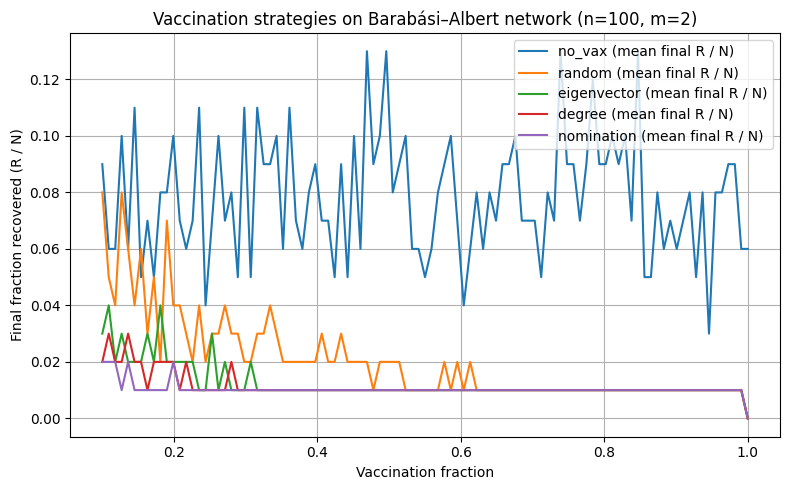

In [6]:
# Plotting results (BA network)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for s in strategies:
    plt.plot(vaccination_fracs, results[s], label=f"{s} (mean final R / N)")
plt.xlabel(r"Vaccination fraction")
plt.ylabel(r"Final fraction recovered (R / N)")
plt.title("Vaccination strategies on Barabási–Albert network (n=100, m=2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("BA_vax_comparison.png", dpi=450)
plt.show()


In [7]:
# --- ER Simulation Loop (patched without modifying helper functions) ---


p = 0.05 # edge probability
G_er = nx.erdos_renyi_graph(n=n, p=p, seed=42)
results_er = {s: np.zeros_like(vaccination_fracs) for s in strategies}

for idx, frac in enumerate(vaccination_fracs):

    k = int(round(frac * n))
    accum = {s: [] for s in strategies}

    for _ in range(n_realizations):

        for s in strategies:

            try:
                vaccinated = selector_map[s](G_er, k)
            except ValueError:
                # fallback: uniformly random vaccination of size k
                vaccinated = set(rng.choice(list(G_er.nodes()), size=min(k, n), replace=False))


            # build subgraph after removing vaccinated
            G_sub = G_er.copy()
            G_sub.remove_nodes_from(vaccinated)

            if G_sub.number_of_nodes() == 0:
                accum[s].append(0)
                continue

            initial_infected = rng.choice(list(G_sub.nodes()))

            t, S, I, R = EoN.fast_SIR(
                G_sub,
                tau=beta,
                gamma=gamma,
                initial_infecteds=[initial_infected]
            )

            final_R = float(R[-1]) if len(R) else 0.0
            accum[s].append(final_R)

    # store mean final recovered fraction
    for s in strategies:
        results_er[s][idx] = statistics.mean(accum[s]) / n


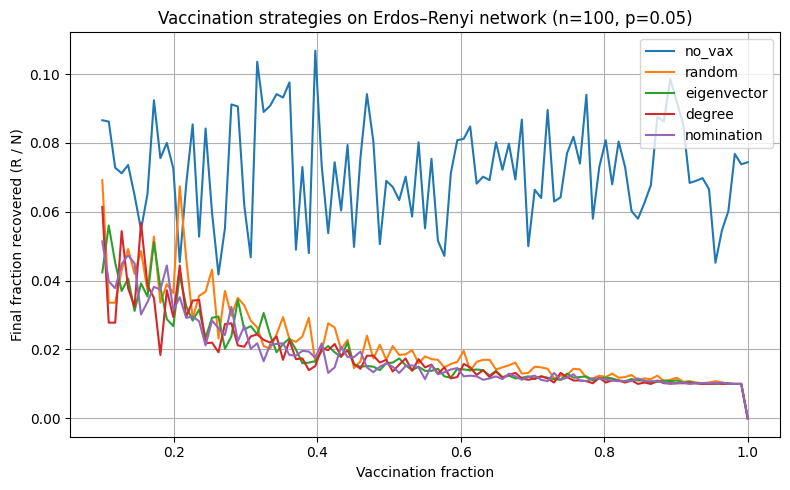

In [9]:
plt.figure(figsize=(8,5))
for s in strategies:
    plt.plot(vaccination_fracs, results_er[s], label=s)

plt.xlabel(r"Vaccination fraction")
plt.ylabel(r"Final fraction recovered (R / N)")
plt.title(f"Vaccination strategies on Erdos–Renyi network (n={n}, p={p})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ER_vax_comparison.png", dpi=450)
plt.show()
